In [1]:
import numpy as np
from DoubleWell import *
import matplotlib.pyplot as plt
from IPython.display import clear_output
import openmm
from openmm import unit
kB = unit.MOLAR_GAS_CONSTANT_R.value_in_unit(unit.kilojoule_per_mole/unit.kelvin)
import torch
import bgflow as bg
ctx = {'dtype': torch.float32, 'device': torch.device('cpu') if torch.cuda.is_available() else torch.device('cpu')}
ctx

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.


{'dtype': torch.float32, 'device': device(type='cpu')}

In [2]:
dim = 2**1
T_l = 150
T_h = 600
modelMD = DoubleWellOpenMM(ModifiedWolfeQuapp(dim))
modelMD.dim, modelMD.MD_dim

(2, 3)

In [7]:
loaded = np.load(f'dw_T600_20ns.npz')
data = loaded['positions']
target_data = torch.as_tensor(data.reshape(len(data),-1)[:,:dim], **ctx)
target_data.shape

torch.Size([10000, 2])

In [8]:
def plot_fes(data, temp=1/kB, bins='auto', w=None, show=True):
    x_samples = assert_numpy(data)
    beta = 1/(temp*kB)
    FES_t = [-np.logaddexp.reduce(-beta*DoubleWellXY[:,i]) for i in range(len(x_bins))]
    FES_t -= min(FES_t)
    plt.plot(x_bins, FES_t, '--', label='reference')
    if w is not None and bins == 'auto':
        bins = 50
    hist, edges = np.histogram(x_samples, bins=bins, weights=w)
    fes_estimate = -np.log(np.where(hist!=0, hist/hist.max(), np.nan))
    xrange = edges[:-1]+(edges[1]-edges[0])/2
    plt.plot(xrange, fes_estimate, label='estimate')
    plt.xlabel('x', fontsize=18)
    plt.ylabel('Free Energy', fontsize=18)
    plt.ylim(0, FES_t[-1])
    plt.xlim(x_bins[0], x_bins[-1])
    plt.legend()
    if show:
        plt.show()
    fes_estimate[np.isnan(fes_estimate)] = 1000
    
    print(f'ref DeltaF: {np.logaddexp.reduce(-FES_t[x_bins<0])-np.logaddexp.reduce(-FES_t[x_bins>0]):g} [kBT]')
    print(f'    DeltaF: {np.logaddexp.reduce(-fes_estimate[xrange<0])-np.logaddexp.reduce(-fes_estimate[xrange>0]):g} [kBT]')

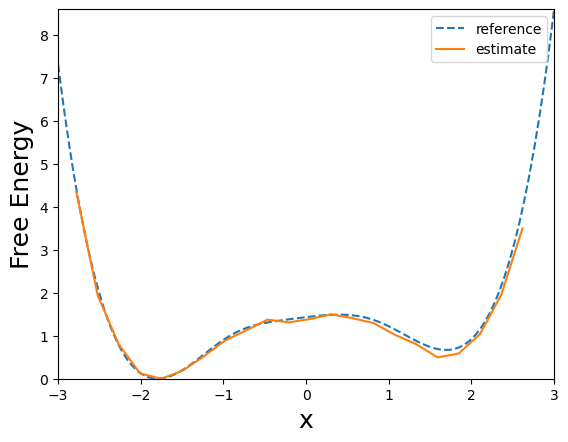

ref DeltaF: 0.529608 [kBT]
    DeltaF: 0.393396 [kBT]


In [10]:
plot_fes(target_data[:,0], T_h)

In [12]:

len_training = int(len(data)*0.8)
prior_data = torch.as_tensor(data.reshape(len(data),-1)[:len_training,:dim], **ctx)
testing_data = torch.as_tensor(data.reshape(len(data),-1)[len_training:,:dim], **ctx)
prior_data.shape, testing_data.shape

(torch.Size([8000, 2]), torch.Size([2000, 2]))

## setup the flow

In [15]:
model = ModifiedWolfeQuapp(dim)
target = ModifiedWolfeQuapp(dim, beta=1/(T_l*kB)).to(**ctx)
prior = bg.CustomDistribution(
    ModifiedWolfeQuapp(dim, beta=1/(T_h*kB)).to(**ctx), 
    bg.DataSetSampler(prior_data[:,:dim], shuffle=True, **ctx)
)
xy_grid, priorMask = get_xy_grid(dim, prior, ctx)

print(f'N = {dim}')

N = 2


In [16]:
#setup the flow
n_coupling = 4
n_splitting = 2
zero_init = True
hidden_nodes = [2**7, 2**7]

assert dim % n_splitting == 0, 'change the splitting scheme to use this dim'
nodes = [dim-dim//n_splitting, *hidden_nodes, dim//n_splitting]
splitting = [dim//n_splitting] * n_splitting
layers = [bg.SplitFlow(*splitting)]
for _ in range(n_coupling):
    for i in range(n_splitting):
        transformer = bg.AffineTransformer(
            shift_transformation=bg.DenseNet(nodes, activation=torch.nn.ReLU()),
            scale_transformation=bg.DenseNet(nodes, activation=torch.nn.ReLU())
        )
        layers.append(bg.CouplingFlow(transformer, transformed_indices=[i], cond_indices=[j for j in range(n_splitting) if j != i]))
layers.append(bg.MergeFlow(*splitting))
bgmap = bg.SequentialFlow(layers).to(**ctx)
generator = bg.BoltzmannGenerator(prior, bgmap, target)

tot_param = sum(p.numel() for p in bgmap.parameters() if p.requires_grad)
print(f"Number of Parameters: {tot_param:_}")

if zero_init:
    for p in bgmap.parameters():
        p.data.fill_(0)
with torch.no_grad():
    print(f'Delta max: {(xy_grid - bgmap(xy_grid)[0]).abs().max().item():g}')
    print(f'dlogp max: {bgmap(xy_grid)[1].abs().max().item():g}')

Number of Parameters: 270_360
Delta max: 0
dlogp max: 0


In [17]:
#setup training
batchsize = 2**7
w_likelihood = 0

optimizer = torch.optim.Adam(generator.parameters(), lr=1e-2)
trainer = bg.KLTrainer(generator, optimizer)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, 1/10, verbose=True)
prior._delegate_sampler.reshuffle_()
if w_likelihood == 0:
    print('energy training only')

energy training only


/home/dell/software/miniforge3/envs/bgflow/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


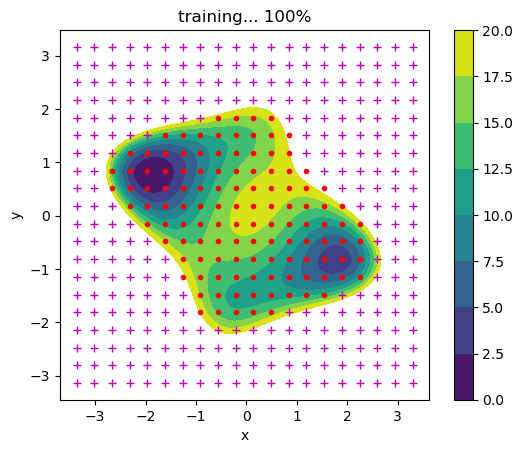

CPU times: user 34min 14s, sys: 19min 2s, total: 53min 17s
Wall time: 1min 7s


In [18]:
%%time
with torch.no_grad():
    mapped_xy = bgmap(xy_grid)[0]
    plot_doublewell(mapped_xy[priorMask], mapped_xy[~priorMask])

stride = 5
n_iter = 100
#run energy training
for i in range(n_iter):
    if i % (n_iter//4) == 0 and i != 0:
        scheduler.step()
    trainer.train(stride, target_data[:,:dim], batchsize=batchsize, w_likelihood=w_likelihood)
    clear_output(wait=True)
    plt.title(f'training... {(i+1)/(n_iter):.0%}')
    with torch.no_grad():
        mapped_xy = bgmap(xy_grid)[0]
        plot_doublewell(mapped_xy[priorMask], mapped_xy[~priorMask])

KLD from 6.54439 to 6.40111
NLL from 1.59591 to 1.58608


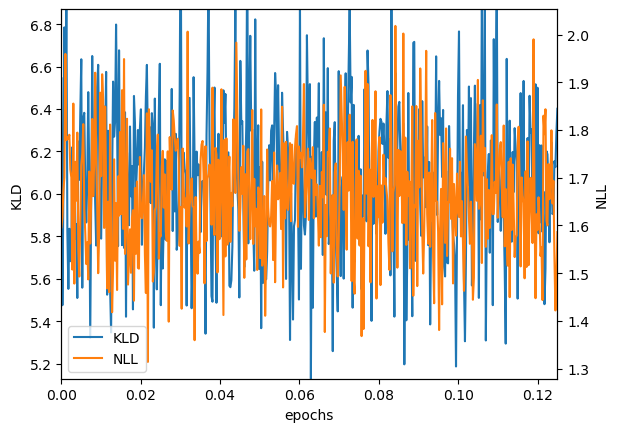

In [19]:
plot_training(trainer.reporter, len_training/batchsize/len(trainer.reporter._raw[0]))

In [23]:
from scipy.ndimage import gaussian_filter
def plot_free_energy_contour(samples, weights=None, range=[[-3, 3], [-3, 3]], cmap=adjusted_cmap, temperature=300, save_path=None):
    k_B = 0.001987 #Boltzmann constant in kcal/(mol*K)
    samples = np.array(samples)
    
    # Generate a 2D histogram
    x_edges = np.linspace(range[0][0], range[0][1], 50)
    y_edges = np.linspace(range[1][0], range[1][1], 50)
    H, x_edges, y_edges = np.histogram2d(
        samples[:, 0], 
        samples[:, 1],
        weights=weights if weights is not None else None,
        bins=[x_edges, y_edges]
    )
    
    H_smooth = gaussian_filter(H, sigma=0.5)

    # Normalize to get probability density
    P = H_smooth / np.sum(H_smooth)

    # Compute free energy
    F = -k_B * temperature * np.log(P + 1e-10)  # Add small value to avoid log(0)
    F -= np.nanmin(F)  # Shift the minimum free energy to zero
    F = np.clip(F, None, 6)
    # Compute the grid for contour plotting
    X, Y = np.meshgrid(x_edges[:-1], y_edges[:-1])
    
    # Plot contours
    plt.figure(figsize=(6, 5))
    contour = plt.contourf(X, Y, F.T, levels=np.linspace(0, 5, 100), cmap=cmap)
    cbar = plt.colorbar(contour)
    cbar.set_ticks([0, 1, 2, 3, 4, 5]) 
 
    cbar.set_label('Free Energy (kcal/mol)', fontsize=18)
    # Set axis labels
    plt.xlabel('x', fontsize=18)
    plt.ylabel('y', fontsize=18)
    plt.xticks(np.arange(-2, 4, 2))  
    plt.yticks(np.arange(-2, 4, 2))
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')  # Save the plot with high resolution
    plt.show()

def plot_result(data, T, range=[-3, 3], dim=2, save_path=save_path):
    """ Plot target energy, bg energy and bg sample histogram"""
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plot_free_energy_contour(data[:,0,:2], save_path=save_path, temperature=T)
    # plot_samples(data[:,0,:2], save_path=save_path)
    # plt.title("Target energy")
    plt.subplot(1, 2, 2)
    plot_fes(data[:,0,0],T)

In [24]:
def plot_samples_on_true_surface(target, samples, XY_range=[-3, 3], T_l=300, 
                                 kB=0.001987, connect_points=False, save_path=None):
    nbins = 101
    beta = 1 / (kB * T_l)
    targetXY = target.energy(torch.as_tensor(XY.T).reshape(nbins**2, 2)).view(nbins, nbins).cpu().numpy().T
    probability = np.exp(-beta * targetXY)
    probability /= np.sum(probability)

    free_energy = -np.log(probability) / beta

    plt.figure(figsize=(7, 6))

    levels = np.linspace(0, 30, 101)
    contour = plt.contourf(XY[0], XY[1], free_energy, levels)
    cbar = plt.colorbar(contour)
    cbar.set_ticks([5, 10, 15, 20, 25, 30]) 
    cbar.set_label('Free Energy', fontsize=18)
    
    plt.scatter(samples[:, 0, 0], samples[:, 0, 1], c='red', s=5, alpha=1, edgecolors='none', label='Samples', zorder=1)
    
    if connect_points:
        plt.plot(samples[:, 0, 0], samples[:, 0, 1], c='red', alpha=0.6, linewidth=1, zorder=1)

    plt.xlabel('x', fontsize=18)
    plt.ylabel('y', fontsize=18)
    plt.xticks(np.arange(-2, 4, 2))
    plt.yticks(np.arange(-2, 4, 2))
    plt.gca().set_box_aspect(1) 
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
    plt.show()

# cMD

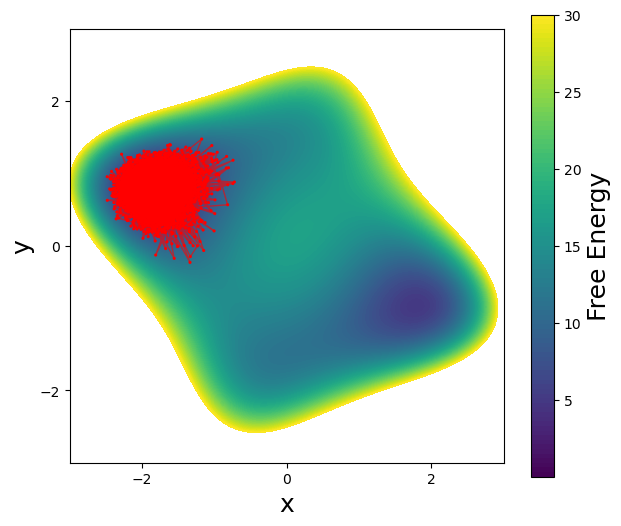

CPU times: user 1min 12s, sys: 29.5 s, total: 1min 42s
Wall time: 1min 13s


In [26]:
%%time
# sample target
pace = 200
n_iter = 10 ** 3 *20
n_equil = 100

from openmm import Platform

platform = Platform.getPlatformByName('CUDA')
properties = {
    'DeviceIndex': '1',        # second GPU (0-based index)
    'Precision': 'mixed'       # or single / double
}

integrator = openmm.LangevinMiddleIntegrator(
    T_l * unit.kelvin,
    10. / unit.picosecond,
    0.005 * unit.picosecond
)

simulation = openmm.app.Simulation(
    modelMD.topology,
    modelMD.system,
    integrator,
    platform,
    properties
)

simulation.context.setPositions(modelMD.positions)


# equilibrate
simulation.step(pace*n_equil)

# run MD
cMD_data = np.full((n_iter, *modelMD.positions.shape), np.nan)
for n in range(n_iter):
    clear_output(wait=True)
    simulation.step(pace)
    cMD_data[n] = simulation.context.getState(getPositions=True).getPositions().value_in_unit(unit.nanometers)
    if (n+1) % (n_iter//1) == 0:
        print(f'-----------------{(n+1) // 1000} ns-----------------', end='\r')
        save_path=f'dim{dim}/cMD_{(n+1)//1000}ns.png'
        plot_samples_on_true_surface(target, cMD_data[:n+1], connect_points=True)

# run REX

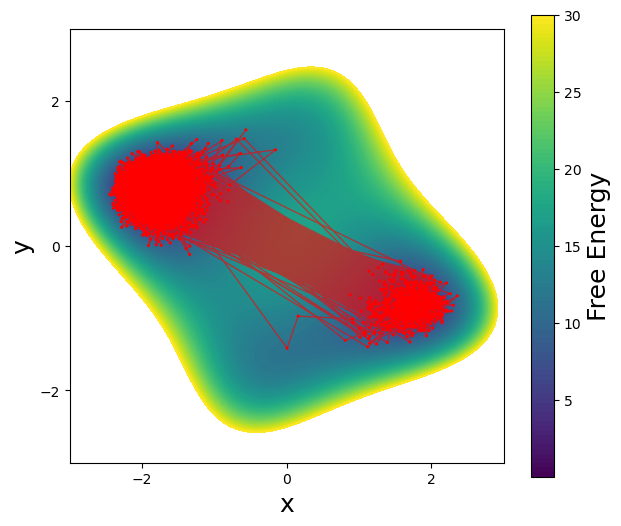

CPU times: user 5min 12s, sys: 4min 7s, total: 9min 19s------------
Wall time: 4min 36s


In [27]:
%%time
import time
import numpy as np
from openmm import Platform

# setup and equilibrate
n_replicas= 2
pace = 200
n_iter = 10 ** 3 * 20
n_equil = 100
temperatures = np.geomspace(T_l, T_h, n_replicas)
platform = Platform.getPlatformByName('CUDA')
properties = {
    'DeviceIndex': '4',
    'Precision': 'mixed'
}

integrator = [openmm.LangevinMiddleIntegrator(T_l*unit.kelvin, 10./unit.picosecond, 0.005*unit.picosecond)]
simulation = [openmm.app.Simulation(modelMD.topology, modelMD.system, integrator[-1],platform,properties)]
initial_pos = [modelMD.positions]
simulation[-1].context.setPositions(initial_pos[-1])
for temp in temperatures[1:]:
    print(f'sampling T = {temp*kB:.2f} ...', end='\r')
    integrator.append(openmm.LangevinMiddleIntegrator(temp*unit.kelvin, 10./unit.picosecond, 0.005*unit.picosecond))
    simulation.append(openmm.app.Simulation(modelMD.topology, modelMD.system, integrator[-1],platform,properties))
    simulation[-1].context.setPositions(initial_pos[-1])
    simulation[-1].step(n_equil*pace)
    initial_pos.append(simulation[-1].context.getState(getPositions=True).getPositions().value_in_unit(unit.nanometers))
initial_pos = np.array(initial_pos)

with np.printoptions(precision=2):
    print('Temperatures:', temperatures)

# sample
is_swapped = np.full((n_replicas, n_iter), False)
Rex_ener = np.full((n_replicas, n_iter), np.nan)
Rex_data = np.full((n_replicas, n_iter, 2), np.nan)
full_data = np.full((2, n_iter, *modelMD.positions.shape), np.nan)

# store cumulative wall-clock time (seconds)
comp_times = np.zeros(n_iter)

# absolute start time before loop
t0 = time.time()

for n in range(n_iter):
    for t in range(n_replicas):
        simulation[t].step(pace)
        Rex_ener[t][n] = simulation[t].context.getState(getEnergy=True).getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole)
        Rex_data[t][n] = np.array(simulation[t].context.getState(getPositions=True).getPositions().value_in_unit(unit.nanometers))[0,:2]
        if t == 0 or t == 1:
            full_data[t][n] = simulation[t].context.getState(getPositions=True).getPositions().value_in_unit(unit.nanometers)

    # replica exchange logic
    for tt in range(n%2, n_replicas-1, 2):
        delta = -(1/(kB*temperatures[tt])-1/(kB*temperatures[tt+1]))*(Rex_ener[tt][n]-Rex_ener[tt+1][n])
        if delta <= 0.0 or np.random.rand() < np.exp(-delta):
            is_swapped[tt][n], is_swapped[tt+1][n] = True, True
            full_data_tt = simulation[tt].context.getState(getPositions=True).getPositions().value_in_unit(unit.nanometers)
            full_data_tt1 = simulation[tt+1].context.getState(getPositions=True).getPositions().value_in_unit(unit.nanometers)
            simulation[tt].context.setPositions(full_data_tt1)
            simulation[tt+1].context.setPositions(full_data_tt)
            simulation[tt].context.setVelocitiesToTemperature(temperatures[tt])
            simulation[tt+1].context.setVelocitiesToTemperature(temperatures[tt+1])

    # cumulative elapsed wall-clock time
    comp_times[n] = time.time() - t0

    if (n+1) % (n_iter//20) == 0:
        clear_output(wait=True)
        current_elapsed = comp_times[n]
        plot_samples_on_true_surface(target, Rex_data[0][:n+1].reshape(-1,1,2), connect_points=True)
        print(f'-----------------Total: {((n+1) // 1000)} ns | Wall Time: {current_elapsed:.1f}s -----------------', end='\r')

    print(f'sampling...  {(n+1)/n_iter:.1%}, accepted: {2*is_swapped[0].sum()/(n+1):.2%}', end='\r')

# save trajectory and wall-clock timestamps
# np.save(f'dim{dim}/REX_{(n_iter)//1000}ns_R{n_replicas}_data.npy', Rex_data)
# np.save(f'dim{dim}/REX_{(n_iter)//1000}ns_R{n_replicas}_times.npy', comp_times)
# np.savez(f'REX_{(n_iter)//1000}ns_R{n_replicas}.npz', data=Rex_data, times=comp_times)

# run res-REX

In [28]:
%%time
import numpy as np
import openmm
import openmm.app
from openmm import unit

# ======================
# Reservoir MD parameters
# ======================
T_res = T_h                     # high temperature
dt = 0.005 * unit.picosecond
total_time_ns = 20              # 20 ns
n_reservoir = reservoir_size = 10_000            # 10,000 structures

total_steps = int((total_time_ns * unit.nanosecond) / dt)
pace = total_steps // n_reservoir   # = 400 steps

print(
    f"Reservoir MD: {total_time_ns} ns | "
    f"Total steps: {total_steps} | "
    f"Pace: {pace}"
)

# ======================
# High-temperature MD simulation
# ======================
res_integrator = openmm.LangevinMiddleIntegrator(
    T_res * unit.kelvin,
    10. / unit.picosecond,
    dt
)

res_simulation = openmm.app.Simulation(
    modelMD.topology,
    modelMD.system,
    res_integrator,platform,properties
)

res_simulation.context.setPositions(modelMD.positions)
res_simulation.context.setVelocitiesToTemperature(T_res * unit.kelvin)

# ======================
# Run MD and collect reservoir structures
# ======================
reservoir = np.empty(
    (n_reservoir, *modelMD.positions.shape),
    dtype=np.float32
)

for i in range(n_reservoir):
    res_simulation.step(pace)
    reservoir[i] = (
        res_simulation
        .context
        .getState(getPositions=True)
        .getPositions()
        .value_in_unit(unit.nanometers)
    )

print(
    f"Reservoir generated: {reservoir.shape} "
    f"at T = {T_res} K"
)

# ======================
# Compute reservoir energies
# ======================
reservoir_energies = np.empty(n_reservoir, dtype=np.float64)

energy_integrator = openmm.LangevinMiddleIntegrator(
    T_res * unit.kelvin,
    10. / unit.picosecond,
    dt
)

energy_simulation = openmm.app.Simulation(
    modelMD.topology,
    modelMD.system,
    energy_integrator,platform,properties
)

for i in range(n_reservoir):
    energy_simulation.context.setPositions(reservoir[i])
    reservoir_energies[i] = (
        energy_simulation
        .context
        .getState(getEnergy=True)
        .getPotentialEnergy()
        .value_in_unit(unit.kilojoule_per_mole)
    )

print(
    f"Reservoir energies done | "
    f"mean = {reservoir_energies.mean():.2f} kJ/mol | "
    f"std = {reservoir_energies.std():.2f}"
)


Reservoir MD: 20 ns | Total steps: 4000000 | Pace: 400
Reservoir generated: (10000, 1, 3) at T = 600 K
Reservoir energies done | mean = 7.80 kJ/mol | std = 5.53
CPU times: user 1min 39s, sys: 24 s, total: 2min 3s
Wall time: 1min 47s


In [22]:

n_replicas = 18
pace = 200
n_iter = 10 ** 3 * 20
n_equil = 100
temperatures = np.geomspace(T_l, T_h, n_replicas)

# res-REX: create replicas R^1 to R^(N-1), excluding the highest temperature
n_sim_replicas = n_replicas - 1
sim_temperatures = temperatures[:-1]  # exclude the highest temperature

integrator = [openmm.LangevinMiddleIntegrator(T_l*unit.kelvin, 10./unit.picosecond, 0.005*unit.picosecond)]
simulation = [openmm.app.Simulation(modelMD.topology, modelMD.system, integrator[-1])]
initial_pos = [modelMD.positions]
simulation[-1].context.setPositions(initial_pos[-1])
for temp in sim_temperatures[1:]:
    print(f'sampling T = {temp:.2f} K ...', end='\r')
    integrator.append(openmm.LangevinMiddleIntegrator(temp*unit.kelvin, 10./unit.picosecond, 0.005*unit.picosecond))
    simulation.append(openmm.app.Simulation(modelMD.topology, modelMD.system, integrator[-1],platform,properties))
    simulation[-1].context.setPositions(initial_pos[-1])
    simulation[-1].step(n_equil*pace)
    initial_pos.append(simulation[-1].context.getState(getPositions=True).getPositions().value_in_unit(unit.nanometers))
initial_pos = np.array(initial_pos)

with np.printoptions(precision=2):
    print('Simulation Temperatures:', sim_temperatures)
    print(f'Reservoir Temperature: {temperatures[-1]:.2f} K')
# data buffers
is_swapped = np.full((n_sim_replicas, n_iter), False)
is_reservoir_swapped = np.full(n_iter, False)  # reservoir swap flag
Rex_ener = np.full((n_sim_replicas, n_iter), np.nan)
Rex_data = np.full((n_sim_replicas, n_iter, 2), np.nan)
full_data = np.full((n_sim_replicas, n_iter, *modelMD.positions.shape), np.nan)

# store cumulative wall-clock time (seconds)
comp_times = np.zeros(n_iter)

# absolute start time before loop
t0 = time.time()

for n in range(n_iter):
    # advance all simulation replicas by one step block
    for t in range(n_sim_replicas):
        simulation[t].step(pace)
        Rex_ener[t][n] = simulation[t].context.getState(getEnergy=True).getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole)
        Rex_data[t][n] = np.array(simulation[t].context.getState(getPositions=True).getPositions().value_in_unit(unit.nanometers))[0,:2]
        full_data[t][n] = simulation[t].context.getState(getPositions=True).getPositions().value_in_unit(unit.nanometers)

    # res-REX exchange logic
    if n % 2 == 0:  # odd-pair attempt: (0-1, 2-3, ...)
        for tt in range(0, n_sim_replicas - 1, 2):
            delta = -(1/(kB*sim_temperatures[tt])-1/(kB*sim_temperatures[tt+1]))*(Rex_ener[tt][n]-Rex_ener[tt+1][n])
            if delta <= 0.0 or np.random.rand() < np.exp(-delta):
                is_swapped[tt][n], is_swapped[tt+1][n] = True, True
                full_data_tt = simulation[tt].context.getState(getPositions=True).getPositions().value_in_unit(unit.nanometers)
                full_data_tt1 = simulation[tt+1].context.getState(getPositions=True).getPositions().value_in_unit(unit.nanometers)
                simulation[tt].context.setPositions(full_data_tt1)
                simulation[tt+1].context.setPositions(full_data_tt)
                simulation[tt].context.setVelocitiesToTemperature(sim_temperatures[tt])
                simulation[tt+1].context.setVelocitiesToTemperature(sim_temperatures[tt+1])
    else:  # even-pair attempt: (1-2, 3-4, ...) plus R^(N-1)-reservoir
        # exchange even-indexed adjacent pairs
        for tt in range(1, n_sim_replicas - 1, 2):
            delta = -(1/(kB*sim_temperatures[tt])-1/(kB*sim_temperatures[tt+1]))*(Rex_ener[tt][n]-Rex_ener[tt+1][n])
            if delta <= 0.0 or np.random.rand() < np.exp(-delta):
                is_swapped[tt][n], is_swapped[tt+1][n] = True, True
                full_data_tt = simulation[tt].context.getState(getPositions=True).getPositions().value_in_unit(unit.nanometers)
                full_data_tt1 = simulation[tt+1].context.getState(getPositions=True).getPositions().value_in_unit(unit.nanometers)
                simulation[tt].context.setPositions(full_data_tt1)
                simulation[tt+1].context.setPositions(full_data_tt)
                simulation[tt].context.setVelocitiesToTemperature(sim_temperatures[tt])
                simulation[tt+1].context.setVelocitiesToTemperature(sim_temperatures[tt+1])

        # exchange R^(N-1) with reservoir
        if n_sim_replicas > 0:
            last_replica_idx = n_sim_replicas - 1
            # randomly select one structure from the reservoir
            reservoir_idx = np.random.randint(0, reservoir_size)
            reservoir_structure = reservoir[reservoir_idx]
            reservoir_energy = reservoir_energies[reservoir_idx]

            # acceptance probability
            last_replica_energy = Rex_ener[last_replica_idx][n]
            delta = -(1/(kB*sim_temperatures[last_replica_idx])-1/(kB*temperatures[-1]))*(last_replica_energy - reservoir_energy)

            if delta <= 0.0 or np.random.rand() < np.exp(-delta):
                is_reservoir_swapped[n] = True
                is_swapped[last_replica_idx][n] = True
                # one-way reservoir read: do not write replica states back to reservoir
                simulation[last_replica_idx].context.setPositions(reservoir_structure)
                simulation[last_replica_idx].context.setVelocitiesToTemperature(sim_temperatures[last_replica_idx])

    # cumulative elapsed wall-clock time
    comp_times[n] = time.time() - t0 
    
    if (n+1) % (n_iter//20) == 0:
        clear_output(wait=True)
        current_elapsed = comp_times[n]
        print(f'-----------------Total: {((n+1) // 1000)} ns | Wall Time: {current_elapsed:.1f}s -----------------', end='\r')

        # plotting block unchanged
        # save_path=f'dim{dim}/res-REX_{(n+1)//1000}ns_R{n_replicas}.png'
        # plot_result(Rex_data[0][:n+1].reshape(-1,1,2),T_l,save_path=save_path)

    # avoid division by zero in reservoir acceptance reporting
    res_denom = (n+1)//2 if (n+1)//2 > 0 else 1
    print(f'sampling...  {(n+1)/n_iter:.1%}, accepted: {2*is_swapped[0].sum()/(n+1):.2%}, reservoir: {is_reservoir_swapped[:n+1].sum()/res_denom:.2%}', end='\r')

# save data (trajectory + wall-clock time)
np.savez(f'dim{dim}/res-REX_{(n_iter)//1000}ns_R{n_replicas}.npz', data=Rex_data, times=comp_times)
# np.save(f'dim{dim}/res-REX_{(n_iter)//1000}ns_R{n_replicas}.npy', Rex_data)
# np.save(f'dim{dim}/res-REX_{(n_iter)//1000}ns_R{n_replicas}_times.npy', comp_times)

# run GREX

In [51]:
bggen_data = torch.Tensor(np.load('BGgen_dw_dim2_T600.npy'))[0:-1:10]
bggen_data.shape

torch.Size([50000, 2])

In [52]:
# Randomly generate Gaussian data, clipped to [-2, 2].
bggen_data_random = torch.clamp(torch.randn(bggen_data.size(0), dim - 2), min=-2, max=2)

# Concatenate original data with random padding dimensions.
bggen_T_h = torch.cat([bggen_data, bggen_data_random], dim=1)
bggen_T_h.shape

torch.Size([50000, 2])

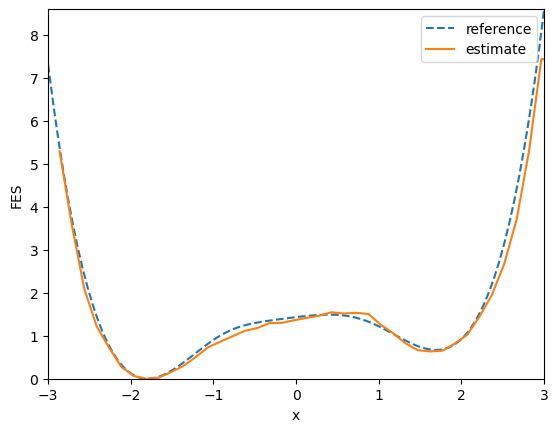

ref DeltaF: 0.529608 [kBT]
    DeltaF: 0.595473 [kBT]


In [53]:
plot_fes(bggen_T_h[:,0], T_h)

In [54]:
xyz = bggen_T_h
with torch.no_grad():
    z_l, dlogp_h = bgmap(torch.Tensor(xyz).to(**ctx), inverse=False)
    logw_h = prior.energy(torch.Tensor(xyz).to(**ctx)) + dlogp_h - target.energy(z_l)
    # logw_h =  - target.energy(z_l)

In [55]:
z_l.shape

torch.Size([50000, 2])

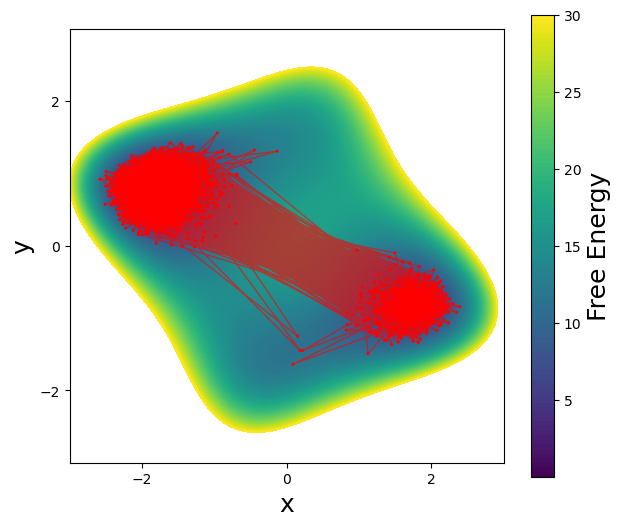

In [57]:
import time
import numpy as np
import torch

# setup and equilibrate
pace = 200   # 1 ps
n_iter = 10 ** 3 * 20
mc_stride = 1

modelMD = DoubleWellOpenMM(model)
initial_pos = modelMD.positions
integrator = openmm.LangevinMiddleIntegrator(
    T_l * unit.kelvin, 10. / unit.picosecond, 0.005 * unit.picosecond
)
simulation = openmm.app.Simulation(modelMD.topology, modelMD.system, integrator)
simulation.context.setPositions(modelMD.positions)
n_equil = 100
# print('equilibrating...', i, end='\r')
simulation.step(n_equil*pace)

data = np.empty((n_iter, *modelMD.positions.shape), dtype=np.float32)
is_swapped = np.zeros(n_iter, dtype=bool)
map_data = np.empty((n_iter, *modelMD.positions.shape), dtype=np.float32)
z_l_len = len(z_l)

# store cumulative wall-clock time (seconds)
comp_times = np.zeros(n_iter)

# absolute start time before loop
t0 = time.time()

for n in range(n_iter):
    simulation.step(pace)
    data[n] = simulation.context.getState(getPositions=True).getPositions().value_in_unit(unit.nanometer)
    
    if n % mc_stride == 0:
        with torch.no_grad():
            random_indices = np.random.choice(z_l_len, size=1, replace=False)
            map_l = z_l[random_indices]
            logw_1 = logw_h[random_indices]        

            md_l = torch.as_tensor(data[n], **ctx).view(1, modelMD.MD_dim)[:, :dim]
            z_map, dlogp_l = bgmap(md_l, inverse=True)
            logw_2 = target.energy(md_l) + dlogp_l - prior.energy(z_map)
            # logw_2 = target.energy(md_l)

        # .item() forces GPU/CPU synchronization for accurate timing.
        delta_energy = -(logw_1 + logw_2).item()
        
        if delta_energy <= 0.0 or np.random.rand() < np.exp(-delta_energy):
            is_swapped[n] = True
            map_data[n] = np.resize(map_l.cpu().numpy(), modelMD.positions.shape)
            simulation.context.setPositions(np.resize(map_l.cpu().numpy(), modelMD.positions.shape))
            simulation.context.setVelocitiesToTemperature(T_l)
            data[n] = simulation.context.getState(getPositions=True).getPositions().value_in_unit(unit.nanometer)

    # cumulative elapsed wall-clock time
    comp_times[n] = time.time() - t0

    if (n+1) % (n_iter//20) == 0:
        clear_output(wait=True)
        current_elapsed = comp_times[n]
        print(f'-----------------Total: {((n+1) // 1000)} ns | Wall Time: {current_elapsed:.1f}s -----------------', end='\r')
        
        # save_path=f'dim{dim}/BGREX_{(n+1)//1000}ns.png'
        # plot_result(data[:n+1], T_l, save_path=save_path)
        plot_samples_on_true_surface(target, data[:n+1], connect_points=True)
        
    print(f'sampling...  {(n+1)/n_iter:.1%}, accepted: {mc_stride*is_swapped[:n+1].sum()/(n+1):.2%}', end='\r')

# save trajectory and wall-clock timestamps
np.savez(f'dim{dim}/BGREX_{(n_iter)//1000}ns.npz', data=data, times=comp_times)
# np.save(f'dim{dim}/BGREX_{(n_iter)//1000}ns.npy', data)

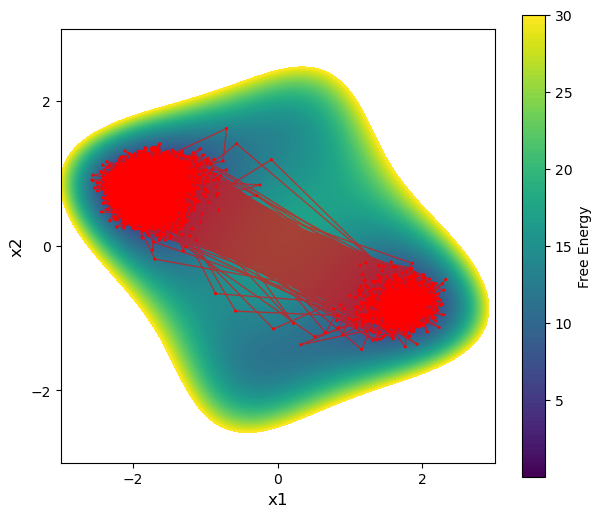

In [52]:
plot_samples_on_true_surface(target, data[:n+1], connect_points=True)

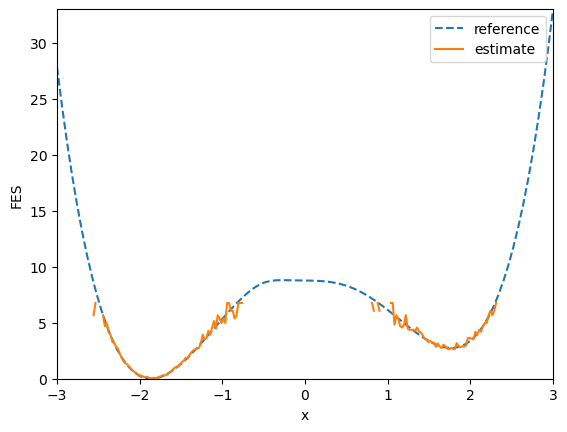

ref DeltaF: 2.62637 [kBT]
    DeltaF: 2.59904 [kBT]


In [38]:
plot_fes(data[:,0,0], T_l)

In [ ]:
np.save(f'GREX_20ns.npy', data)